# Model Comparison

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Per-Class Metrics -- In-Distribution vs LOCO

In [3]:
# Create a DataFrame to summarize the results for the human class (label=0)
data_human = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Stylometric + LR', 'DistilBERT', 'Zero-shot LLM'],
    'Acc (ID)':   [0.9207, 0.7953, 0.9562, 0.5580],
    'Prec (ID)':  [0.9146, 0.84, 0.9786, 0.53],
    'Rec (ID)':   [0.928, 0.74, 0.9329, 0.99],
    'F1 (ID)':    [0.9212, 0.78, 0.9552, 0.69],
    'Acc (LOCO)': [0.8903, 0.8034, 0.9510, float('nan')],
    'Prec (LOCO)': [0.8583, 0.8325, 0.9649, float('nan')],
    'Rec (LOCO)':  [0.9271, 0.7631, 0.9354, float('nan')],
    'F1 (LOCO)':   [0.8895, 0.7928, 0.9492, float('nan')],
}).set_index('Model')

data_human['Gap F1'] = data_human['F1 (LOCO)'] - data_human['F1 (ID)']

print('=== Human Class (label=0) ===')
display(data_human.round(4))

=== Human Class (label=0) ===


,Acc (ID),Prec (ID),Rec (ID),F1 (ID),Acc (LOCO),Prec (LOCO),Rec (LOCO),F1 (LOCO),Gap F1
Model,,,,,,,,,
TF-IDF + LR,0.9207,0.9146,0.9280,0.9212,0.8903,0.8583,0.9271,0.8895,-0.0317
Stylometric + LR,0.7953,0.8400,0.7400,0.7800,0.8034,0.8325,0.7631,0.7928,0.0128
DistilBERT,0.9562,0.9786,0.9329,0.9552,0.9510,0.9649,0.9354,0.9492,-0.0060
Zero-shot LLM,0.5580,0.5300,0.9900,0.6900,NaN,NaN,NaN,NaN,NaN


In [4]:
# Create a DataFrame to summarize the results for the AI class (label=1)
data_ai = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Stylometric + LR', 'DistilBERT', 'Zero-shot LLM'],
    'Acc (ID)':   [0.9207, 0.7953, 0.9562, 0.5580],
    'Prec (ID)':  [0.9269, 0.76, 0.9359, 0.92],
    'Rec (ID)':   [0.9133, 0.85, 0.9796, 0.13],
    'F1 (ID)':    [0.9201, 0.81, 0.9572, 0.22],
    'Acc (LOCO)': [0.8903, 0.8034, 0.9510, float('nan')],
    'Prec (LOCO)': [0.9204, 0.7678, 0.9347, float('nan')],
    'Rec (LOCO)':  [0.8477, 0.8402, 0.9657, float('nan')],
    'F1 (LOCO)':   [0.88, 0.8008, 0.9491, float('nan')],
}).set_index('Model')

data_ai['Gap F1'] = data_ai['F1 (LOCO)'] - data_ai['F1 (ID)']

print('=== AI Class (label=1) ===')
display(data_ai.round(4))

=== AI Class (label=1) ===


,Acc (ID),Prec (ID),Rec (ID),F1 (ID),Acc (LOCO),Prec (LOCO),Rec (LOCO),F1 (LOCO),Gap F1
Model,,,,,,,,,
TF-IDF + LR,0.9207,0.9269,0.9133,0.9201,0.8903,0.9204,0.8477,0.8800,-0.0401
Stylometric + LR,0.7953,0.7600,0.8500,0.8100,0.8034,0.7678,0.8402,0.8008,-0.0092
DistilBERT,0.9562,0.9359,0.9796,0.9572,0.9510,0.9347,0.9657,0.9491,-0.0081
Zero-shot LLM,0.5580,0.9200,0.1300,0.2200,NaN,NaN,NaN,NaN,NaN


## Macro-F1 (Average of Human + AI F1)

In [5]:
# Compute Macro-F1 as the average of Human and AI F1 scores for each model
data_macro = pd.DataFrame({
    'Model': ['TF-IDF + LR', 'Stylometric + LR', 'DistilBERT', 'Zero-shot LLM'],
    'Macro-F1 (ID)':   [(0.9212+0.9201)/2, (0.78+0.81)/2, (0.9552+0.9572)/2, (0.69+0.22)/2],
    'Macro-F1 (LOCO)': [(0.8895+0.8800)/2, (0.7928+0.8008)/2, (0.9492+0.9491)/2, float('nan')],
}).set_index('Model')

data_macro['Gap'] = data_macro['Macro-F1 (LOCO)'] - data_macro['Macro-F1 (ID)']

print('=== Macro-F1 (avg of Human + AI) ===')
display(data_macro.round(4))

=== Macro-F1 (avg of Human + AI) ===


,Macro-F1 (ID),Macro-F1 (LOCO),Gap
Model,,,
TF-IDF + LR,0.9206,0.8848,-0.0359
Stylometric + LR,0.7950,0.7968,0.0018
DistilBERT,0.9562,0.9492,-0.0070
Zero-shot LLM,0.4550,NaN,NaN


## Heatmap -- F1 Drop (ID - LOCO) per Category -- Human Class

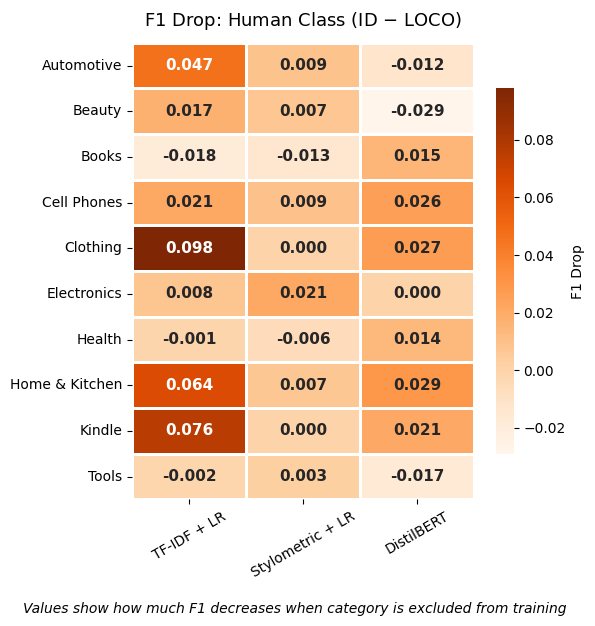

Avg F1 drop:  TF-IDF=0.0310  Stylometric=0.0038  DistilBERT=0.0074


In [6]:
# create heatmap to show the F1 Drop when comparing Leave-One-Category-Out to in-distribution for HUman Class
categories = [
    'Automotive', 'Beauty', 'Books',
    'Cell Phones', 'Clothing',
    'Electronics', 'Health', 'Home & Kitchen',
    'Kindle', 'Tools'
]

f1h_id_tfidf = [0.9697, 0.9346, 0.9231, 0.8943, 0.9071, 0.9463, 0.9252, 0.9415, 0.8511, 0.9123]
f1h_loc_tfidf = [0.9231, 0.9174, 0.9412, 0.873, 0.8092, 0.9384, 0.9262, 0.8772, 0.7755, 0.9138]
f1h_id_sty = [0.8511, 0.7647, 0.7797, 0.8189, 0.7692, 0.8039, 0.8201, 0.7183, 0.8077, 0.8319]
f1h_loc_sty = [0.8421, 0.7573, 0.7931, 0.8095, 0.7692, 0.7826, 0.8261, 0.7113, 0.8077, 0.8288]
f1h_id_bert = [0.968, 0.942, 0.933, 0.961, 0.938, 0.961, 0.966, 0.962, 0.978, 0.957]
f1h_loc_bert = [0.980, 0.971, 0.918, 0.935, 0.911, 0.961, 0.952, 0.933, 0.957, 0.974]

drop_human = pd.DataFrame({
    'TF-IDF + LR': [round(i - l, 4) for i, l in zip(f1h_id_tfidf, f1h_loc_tfidf)],
    'Stylometric + LR': [round(i - l, 4) for i, l in zip(f1h_id_sty, f1h_loc_sty)],
    'DistilBERT': [round(i - l, 4) for i, l in zip(f1h_id_bert, f1h_loc_bert)],
}, index=categories)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(drop_human, annot=True, cmap='Oranges', fmt='.3f',
            ax=ax, linewidths=1, linecolor='white',
            cbar_kws={'label': 'F1 Drop', 'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('F1 Drop: Human Class (ID $-$ LOCO)', fontsize=13, pad=12)
fig.text(0.5, -0.03, 'Values show how much F1 decreases when category is excluded from training',
         ha='center', fontsize=10, style='italic')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f'Avg F1 drop:  TF-IDF={drop_human["TF-IDF + LR"].mean():.4f}  '
      f'Stylometric={drop_human["Stylometric + LR"].mean():.4f}  '
      f'DistilBERT={drop_human["DistilBERT"].mean():.4f}')

## Heatmap -- F1 Drop (ID - LOCO) per Category -- AI Class

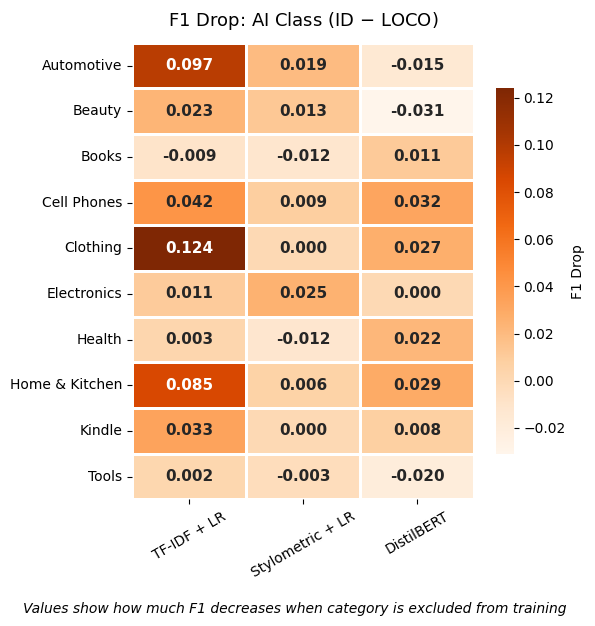

Avg F1 drop:  TF-IDF=0.0411  Stylometric=0.0045  DistilBERT=0.0063


In [7]:
# create heatmap to show the F1 Drop when comparing Leave-One-Category-Out to in-distribution for AI Class
f1a_id_tfidf = [0.9492, 0.9263, 0.9451, 0.8471, 0.9226, 0.9502, 0.8842, 0.9365, 0.9440, 0.9057]
f1a_loc_tfidf = [0.8519, 0.9032, 0.9545, 0.8049, 0.7986, 0.9395, 0.8817, 0.8511, 0.9106, 0.9038]
f1a_id_sty = [0.7813, 0.7600, 0.8660, 0.7160, 0.8492, 0.8198, 0.7573, 0.7647, 0.9167, 0.8224]
f1a_loc_sty = [0.7619, 0.7475, 0.8776, 0.7073, 0.8492, 0.7945, 0.7692, 0.7588, 0.9167, 0.8257]
f1a_id_bert = [0.952, 0.939, 0.958, 0.937, 0.952, 0.964, 0.948, 0.961, 0.992, 0.951]
f1a_loc_bert = [0.967, 0.970, 0.947, 0.905, 0.925, 0.964, 0.926, 0.932, 0.984, 0.971]

drop_ai = pd.DataFrame({
    'TF-IDF + LR': [round(i - l, 4) for i, l in zip(f1a_id_tfidf, f1a_loc_tfidf)],
    'Stylometric + LR': [round(i - l, 4) for i, l in zip(f1a_id_sty, f1a_loc_sty)],
    'DistilBERT': [round(i - l, 4) for i, l in zip(f1a_id_bert, f1a_loc_bert)],
}, index=categories)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(drop_ai, annot=True, cmap='Oranges', fmt='.3f',
            ax=ax, linewidths=1, linecolor='white',
            cbar_kws={'label': 'F1 Drop', 'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('F1 Drop: AI Class (ID $-$ LOCO)', fontsize=13, pad=12)
fig.text(0.5, -0.03, 'Values show how much F1 decreases when category is excluded from training',
         ha='center', fontsize=10, style='italic')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f'Avg F1 drop:  TF-IDF={drop_ai["TF-IDF + LR"].mean():.4f}  '
      f'Stylometric={drop_ai["Stylometric + LR"].mean():.4f}  '
      f'DistilBERT={drop_ai["DistilBERT"].mean():.4f}')

## LOCO vs In-Distribution -- TF-IDF + LR

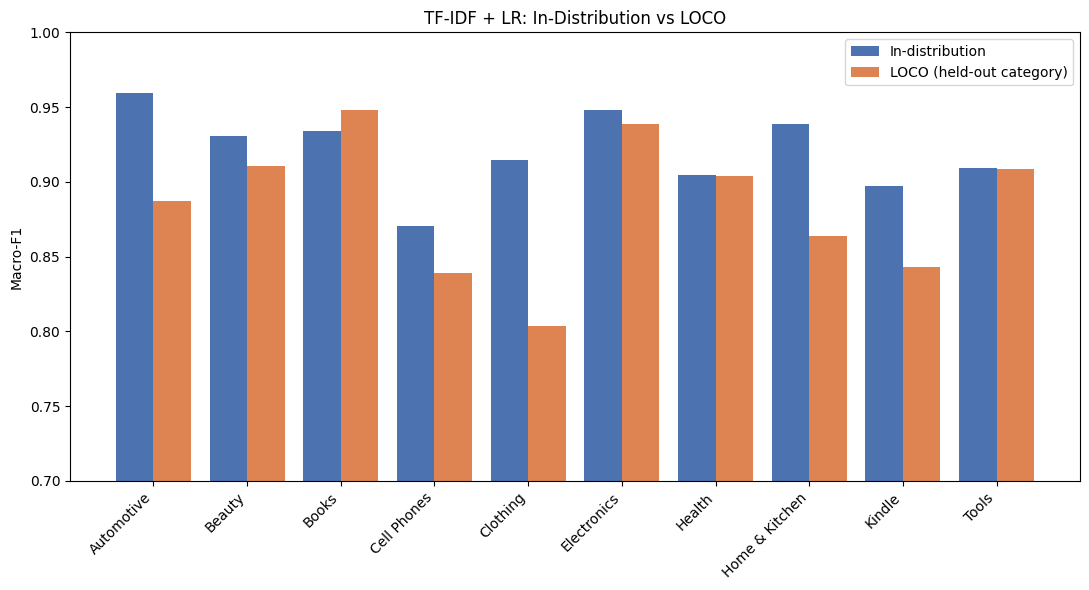

In [8]:
# create plot to compare in-distribution vs LOCO on each category in TF-IDF+LR
tfidf_id_f1 = [0.9594, 0.9404, 0.9346, 0.8508, 0.9148, 0.9249, 0.9226, 0.9358, 0.8555, 0.9088]
tfidf_loco_f1 = [0.8875, 0.9103, 0.9479, 0.8389, 0.8039, 0.939, 0.9039, 0.8641, 0.843, 0.9088]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(categories))
ax.bar(x - 0.2, tfidf_id_f1, width=0.4, label='In-distribution', color='#4C72B0')
ax.bar(x + 0.2, tfidf_loco_f1, width=0.4, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.7, 1.0)
ax.set_title('TF-IDF + LR: In-Distribution vs LOCO')
ax.legend()
plt.tight_layout()
plt.show()

## LOCO vs In-Distribution -- Stylometric + LR

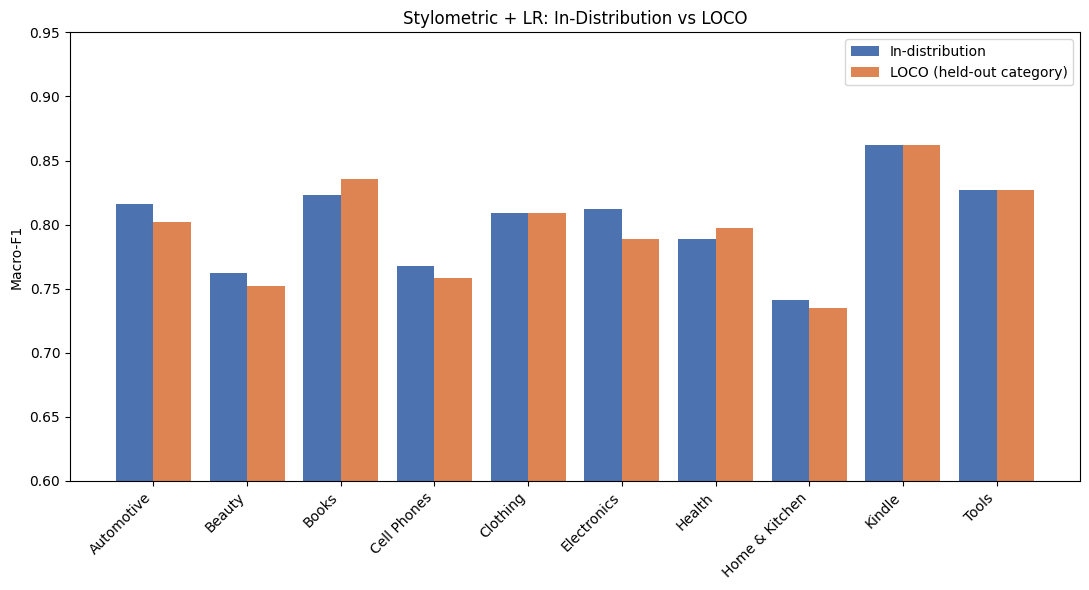

In [9]:
# create plot to compare in-distribution vs LOCO on each category in Stylometric + LR
sty_id_f1 = [0.8020, 0.7425, 0.8079, 0.7584, 0.8059, 0.8120, 0.7897, 0.7452, 0.8622, 0.8271]
sty_loco_f1 = [0.8020, 0.7524, 0.8354, 0.7584, 0.8092, 0.7886, 0.7977, 0.7351, 0.8622, 0.8273]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(categories))
ax.bar(x - 0.2, sty_id_f1, width=0.4, label='In-distribution', color='#4C72B0')
ax.bar(x + 0.2, sty_loco_f1, width=0.4, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.6, 0.95)
ax.set_title('Stylometric + LR: In-Distribution vs LOCO')
ax.legend()
plt.tight_layout()
plt.show()

## LOCO vs In-Distribution -- DistilBERT

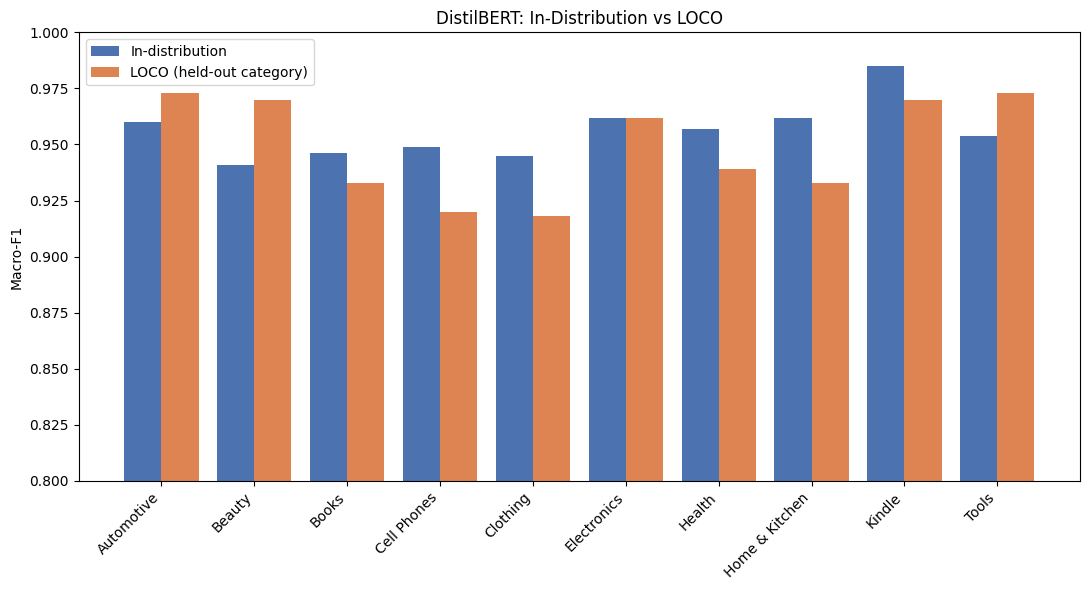

In [10]:
# create plot to compare in-distribution vs LOCO on each category in DistilBERT
bert_id_f1 = [0.960, 0.941, 0.946, 0.949, 0.945, 0.962, 0.957, 0.962, 0.985, 0.954]
bert_loco_f1 = [0.973, 0.970, 0.933, 0.920, 0.918, 0.962, 0.939, 0.933, 0.970, 0.973]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(categories))
ax.bar(x - 0.2, bert_id_f1, width=0.4, label='In-distribution', color='#4C72B0')
ax.bar(x + 0.2, bert_loco_f1, width=0.4, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.8, 1.0)
ax.set_title('DistilBERT: In-Distribution vs LOCO')
ax.legend()
plt.tight_layout()
plt.show()

## Combined In-Distribution vs LOCO (All Models)

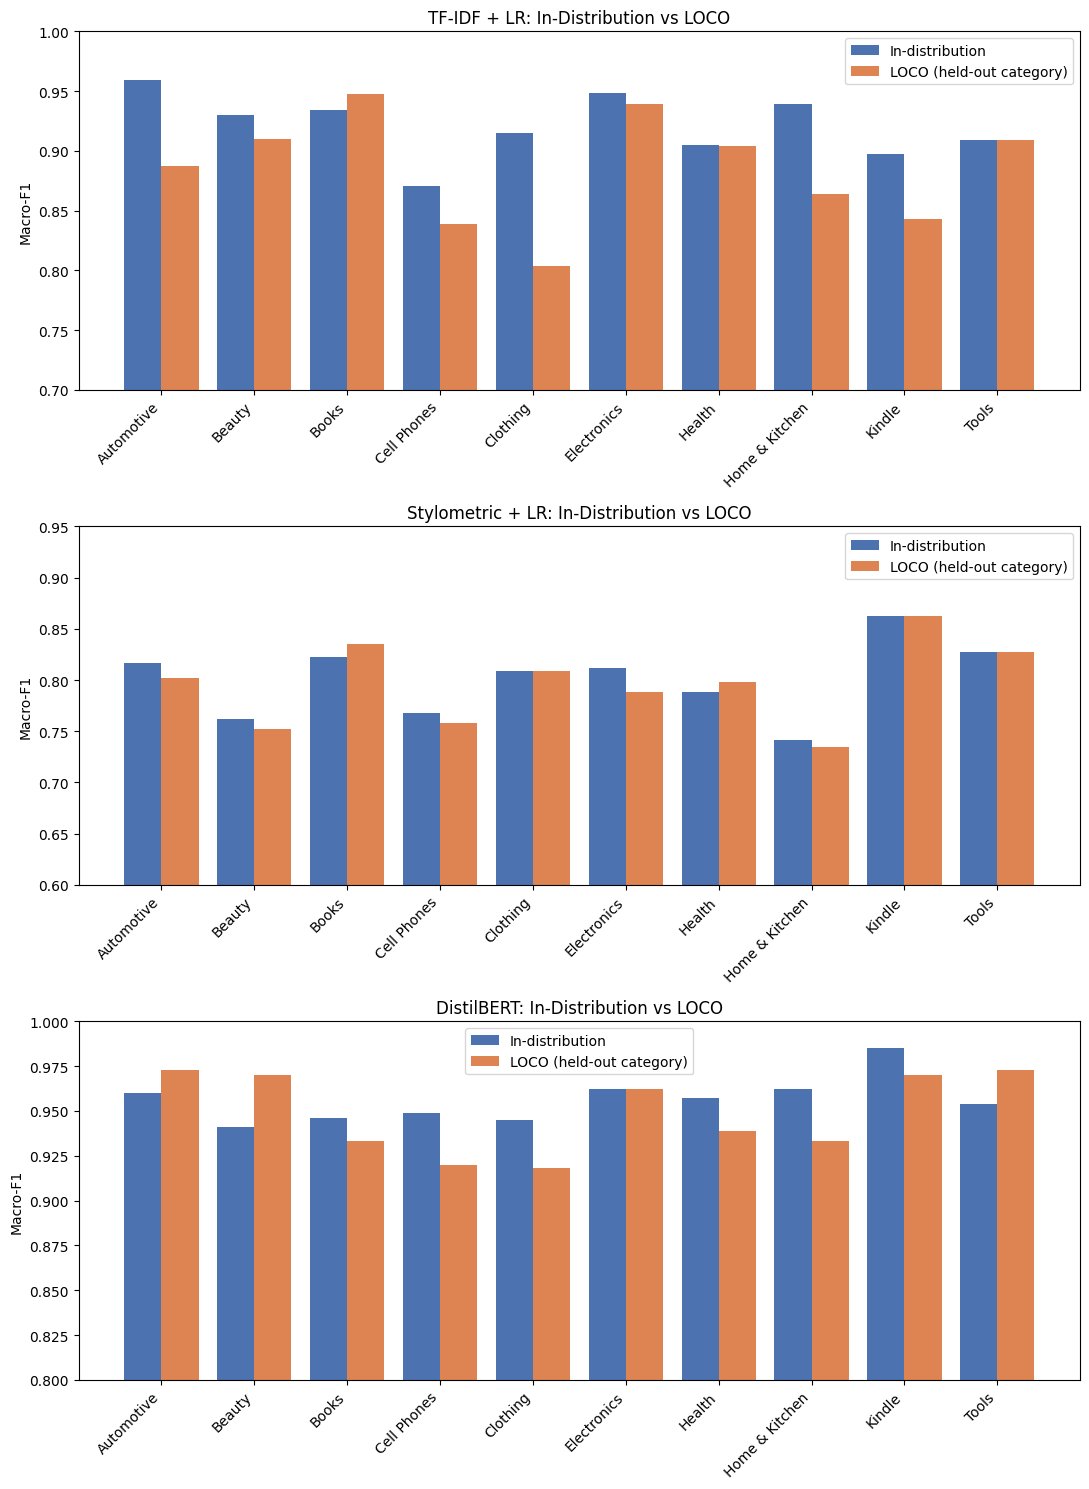

In [11]:
# Create a combined figure with all three models stacked vertically for the appendix
fig, axes = plt.subplots(3, 1, figsize=(11, 15))
x = np.arange(len(categories))
w = 0.4

ax = axes[0]
ax.bar(x - w/2, tfidf_id_f1, width=w, label='In-distribution', color='#4C72B0')
ax.bar(x + w/2, tfidf_loco_f1, width=w, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.7, 1.0)
ax.set_title('TF-IDF + LR: In-Distribution vs LOCO')
ax.legend()

ax = axes[1]
ax.bar(x - w/2, sty_id_f1, width=w, label='In-distribution', color='#4C72B0')
ax.bar(x + w/2, sty_loco_f1, width=w, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.6, 0.95)
ax.set_title('Stylometric + LR: In-Distribution vs LOCO')
ax.legend()

ax = axes[2]
ax.bar(x - w/2, bert_id_f1, width=w, label='In-distribution', color='#4C72B0')
ax.bar(x + w/2, bert_loco_f1, width=w, label='LOCO (held-out category)', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Macro-F1')
ax.set_ylim(0.8, 1.0)
ax.set_title('DistilBERT: In-Distribution vs LOCO')
ax.legend()

plt.tight_layout()
plt.savefig('loco_vs_id_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## All Models Side-by-Side -- Generalization Gap

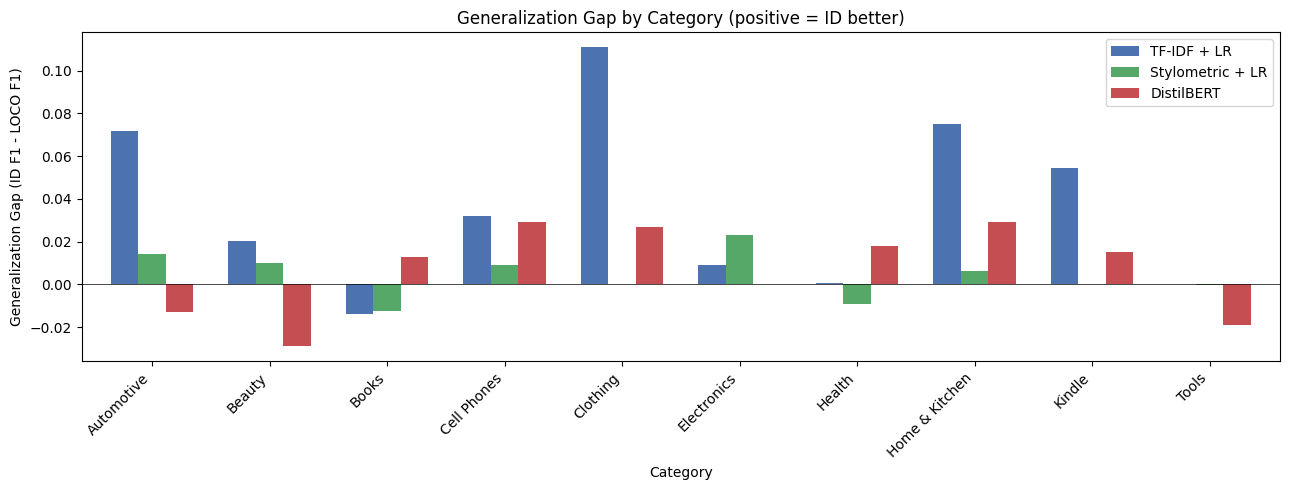

=== Generalization Gaps ===


,TF-IDF + LR,Stylometric + LR,DistilBERT
Category,,,
Automotive,0.0719,0.0142,-0.013
Beauty,0.0201,0.0100,-0.029
Books,-0.0138,-0.0126,0.013
Cell Phones,0.0318,0.0091,0.029
Clothing,0.1109,0.0000,0.027
Electronics,0.0093,0.0233,0.000
Health,0.0008,-0.0090,0.018
Home & Kitchen,0.0749,0.0064,0.029
Kindle,0.0545,0.0000,0.015



Avg gap:  TF-IDF=0.0361  Stylometric=0.0041  DistilBERT=0.0070


In [12]:
# plot to generalize the F1 drop across all models
tfidf_gaps = [round(i - l, 4) for i, l in zip(tfidf_id_f1, tfidf_loco_f1)]
sty_gaps = [round(i - l, 4) for i, l in zip(sty_id_f1, sty_loco_f1)]
bert_gaps = [round(i - l, 4) for i, l in zip(bert_id_f1, bert_loco_f1)]

gap_df = pd.DataFrame({
    'Category': categories,
    'TF-IDF + LR': tfidf_gaps,
    'Stylometric + LR': sty_gaps,
    'DistilBERT': bert_gaps,
}).set_index('Category')

fig, ax = plt.subplots(figsize=(13, 5))
gap_df.plot(kind='bar', ax=ax, width=0.7,
            color=['#4C72B0', '#55A868', '#C44E52'])
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Generalization Gap (ID F1 - LOCO F1)')
ax.set_title('Generalization Gap by Category (positive = ID better)')
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('=== Generalization Gaps ===')
display(gap_df)
print(f'\nAvg gap:  TF-IDF={np.mean(tfidf_gaps):.4f}  '
      f'Stylometric={np.mean(sty_gaps):.4f}  '
      f'DistilBERT={np.mean(bert_gaps):.4f}')

## Notes
- **Zero-shot LLM**: Excluded from LOCO (API model, no training per category)
- **TF-IDF + LR ID**: Accuracy=0.9207, Human Prec=0.9146/Rec=0.9280/F1=0.9212, AI Prec=0.9269/Rec=0.9133/F1=0.9201
- **TF-IDF LOCO per-class**: Updated from TF-IDF_LR_Model.ipynb. Human Prec=0.8583/Rec=0.9271/F1=0.8895, AI Prec=0.9204/Rec=0.8477/F1=0.8800
- **TF-IDF per-category ID F1**: Now computed in TF-IDF_LR_Model.ipynb. Re-run that notebook and copy the printed values here.
- **Stylometric + LR ID**: Accuracy=0.7953, Human Prec=0.84/Rec=0.74/F1=0.78, AI Prec=0.76/Rec=0.85/F1=0.81
- **Stylometric LOCO per-class**: Updated from Stylometric_features.ipynb. Per-category ID F1 now computed in Stylometric notebook (re-run and copy values here).
- **DistilBERT ID**: 3-seed average overall (Acc=0.9562). Per-category from seed 42. Human Prec=0.9786/Rec=0.9329/F1=0.9552, AI Prec=0.9359/Rec=0.9796/F1=0.9572
- **DistilBERT LOCO**: 1 seed per fold, updated from Colab notebook.
- **IMPORTANT**: Re-run this notebook to regenerate all charts and tables with updated values.